# Can we trust the confidence score?

Every label the model produces comes with a **confidence**. If it were trustworthy,
wrong labels would carry lower confidence than right ones.


In [1]:
import os
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from dmpbridge.core import paths as P
from dmpbridge.evaluation.evaluate import (
    containment, extract_gold, resolve_old_gt_path, tokenize,
)

MODELS = ['llama3.1:8b', 'gemma4:e4b', 'llama3.3:70b']
EXTRACTOR = 'pdfplumber'
SAMPLES = range(1, 11)


## Step 1 — Load the labeled JSON

One entry per **line** of the PDF, each with a label and a confidence.


In [2]:
lines = json.loads(P.labeled_path(P.make_tag('llama3.1:8b', EXTRACTOR), 1)
                   .read_text(encoding='utf-8'))
print(f'{len(lines)} lines in sample 1')
display(pd.DataFrame(lines)[['text', 'label', 'confidence']].head(4))


78 lines in sample 1


,text,label,confidence
0,DATA MANAGEMENT AND SHARING PLAN,title,1.0
1,Element 1: Data Type:,section.title,1.0
2,A. Types and amount of scientific data expecte...,question.text,1.0
3,This secondary data analysis project will anal...,answer.text,1.0


## Step 2 — Join the lines back into items

A paragraph is several lines in the PDF but **one item** in the annotation. So
neighbouring lines with the same label are put back together — exactly what the
pipeline does when it builds its final output.


In [3]:
def join_lines(lines):
    """Neighbouring lines with the same label become one item."""
    items, current = [], None
    for line in lines:
        if current is not None and current['label'] == line['label']:
            current['text'] += ' ' + line['text']
            current['line_confidences'].append(float(line['confidence']))
        else:
            if current is not None:
                items.append(current)
            current = {'label': line['label'], 'text': line['text'],
                       'line_confidences': [float(line['confidence'])]}
    if current is not None:
        items.append(current)
    return items


items = join_lines(lines)
print(f'{len(lines)} lines  ->  {len(items)} items')


78 lines  ->  30 items


## Step 3 — One confidence per item: the lowest of its lines

A paragraph is only as trustworthy as its shakiest line.


In [4]:
biggest = max(items, key=lambda it: len(it['line_confidences']))
print(f"an item made of {len(biggest['line_confidences'])} lines")
print(f"  line confidences : {biggest['line_confidences']}")
print(f"  lowest           : {min(biggest['line_confidences'])}  <- the item's confidence")


an item made of 12 lines
  line confidences : [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
  lowest           : 1.0  <- the item's confidence


## Step 4 — Check every item against the annotation

The same steps for every model and all 10 documents: load, join, take the lowest
confidence, compare with the annotation.


In [5]:
def true_label_of(item, annotation):
    """The label of the annotation paragraph this item belongs to, or None."""
    words = tokenize(item['text'])
    if len(words) < 3:
        return None
    best_score, best_label = 0.0, None
    for gold_text, gold_label in annotation:
        score = containment(words, tokenize(gold_text))
        if score > best_score:
            best_score, best_label = score, gold_label
    return best_label if best_score >= 0.75 else None


rows = []
for sample in SAMPLES:
    annotation = extract_gold(resolve_old_gt_path(sample))
    for model in MODELS:
        path = P.labeled_path(P.make_tag(model, EXTRACTOR), sample)
        for item in join_lines(json.loads(path.read_text(encoding='utf-8'))):
            true_label = true_label_of(item, annotation)
            if true_label is None:
                continue
            rows.append({'model': model,
                         'confidence': min(item['line_confidences']),
                         'correct': item['label'] == true_label,
                         'true label': true_label,
                         'model said': item['label'],
                         'text': item['text']})

df = pd.DataFrame(rows)
print(f'{len(df)} items checked across {len(MODELS)} models and 10 documents')


768 items checked across 3 models and 10 documents


## The result


In [6]:
table = (df.groupby('model')
         .apply(lambda d: pd.Series({
             'Accuracy, %': d['correct'].mean() * 100,
             'Total confidence, %': d['confidence'].mean() * 100,
             'Confidence for correct answer, %':
                 d[d['correct']]['confidence'].mean() * 100,
             'Confidence for incorrect answer, %':
                 d[~d['correct']]['confidence'].mean() * 100,
         }), include_groups=False)
         .reindex(MODELS))
table.index.name = 'Model'
display(table.style.format('{:.1f}'))


,"Accuracy, %","Total confidence, %","Confidence for correct answer, %","Confidence for incorrect answer, %"
Model,,,,
llama3.1:8b,49.1,89.2,89.4,89.0
gemma4:e4b,75.5,94.7,95.9,91.1
llama3.3:70b,75.1,86.5,87.6,83.2


**Read the last two columns.** If confidence worked, the last column would be much
lower than the one before it — mistakes arriving with visible doubt. They are almost
the same.

**And compare the first two.** Every model claims far more confidence than its
accuracy justifies.


### A real example from each case

Splitting items by confidence (high = 0.9 or more) and by whether they were right.
The second row is the one that matters.


In [7]:
M = MODELS[0]
d = df[df['model'] == M].copy()
d['high confidence'] = d['confidence'] >= 0.9

picks = []
for high, ok, name in ((True, True, 'high confidence + correct'),
                       (True, False, 'high confidence + INCORRECT'),
                       (False, True, 'low confidence + correct'),
                       (False, False, 'low confidence + incorrect')):
    sub = d[(d['high confidence'] == high) & (d['correct'] == ok)]
    if len(sub):
        r = sub.sort_values('confidence', ascending=not high).iloc[0]
        picks.append({'case': name, 'confidence': f"{r['confidence']:.2f}",
                      'true label': r['true label'],
                      'model said': r['model said'],
                      'text': r['text'][:64]})
    else:
        picks.append({'case': name, 'confidence': '—', 'true label': '—',
                      'model said': '—', 'text': '(no items in this case)'})

print(f'{M}\n')
display(pd.DataFrame(picks).set_index('case'))


llama3.1:8b



,confidence,true label,model said,text
case,,,,
high confidence + correct,1.00,title,title,DATA MANAGEMENT AND SHARING PLAN
high confidence + INCORRECT,1.00,question.text,section.title,B. Scientific data that will be preserved and ...
low confidence + correct,0.10,answer.text,answer.text,The proposed research in this proposal include...
low confidence + incorrect,0.55,section.description,question.text,Data management plans should provide a plan fo...


## Large language models' mean confidence scores for correct and incorrect answers

Two rows per model. The **dot** is the mean confidence — the last two columns of the
table above. The **bar behind it** covers the middle 80% of the individual items
(the 10th to the 90th percentile), which is what shows whether the two groups are
really apart or only look it.

> The spread is shown as percentiles rather than ± 1 SD because confidence cannot go
> above 100%, and most items sit right at the ceiling. A symmetric SD bar runs past
> 100% — into a region where no item can exist.


In [8]:
sd_table = pd.DataFrame([
    {'Model': m,
     'Confidence when incorrect (%), mean (SD)':
         '{:.1f} ({:.1f})'.format(
             df[(df['model'] == m) & (~df['correct'])]['confidence'].mean() * 100,
             df[(df['model'] == m) & (~df['correct'])]['confidence'].std() * 100),
     'Confidence when correct (%), mean (SD)':
         '{:.1f} ({:.1f})'.format(
             df[(df['model'] == m) & (df['correct'])]['confidence'].mean() * 100,
             df[(df['model'] == m) & (df['correct'])]['confidence'].std() * 100)}
    for m in MODELS]).set_index('Model')

display(sd_table.style
        .set_caption("Large language models' mean confidence scores for "
                     'correct and incorrect answers')
        .set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'caption',
             'props': [('caption-side', 'top'), ('font-weight', 'bold'),
                       ('font-size', '105%'), ('text-align', 'left'),
                       ('padding-bottom', '10px')]},
            {'selector': 'th.col_heading',
             'props': [('text-align', 'center'), ('vertical-align', 'bottom'),
                       ('max-width', '190px'), ('white-space', 'normal')]},
            {'selector': 'th.row_heading', 'props': [('text-align', 'left')]},
        ]))


,"Confidence when incorrect (%), mean (SD)","Confidence when correct (%), mean (SD)"
Model,,
llama3.1:8b,89.0 (10.9),89.4 (16.0)
gemma4:e4b,91.1 (6.9),95.9 (4.3)
llama3.3:70b,83.2 (11.4),87.6 (11.2)


The two columns are almost the same for every model, and the SD in brackets is far
larger than the difference between them — the numbers behind these two means are
drawn from more or less the same range.


saved for slides -> Report-doc\confidence_correct_vs_incorrect.png


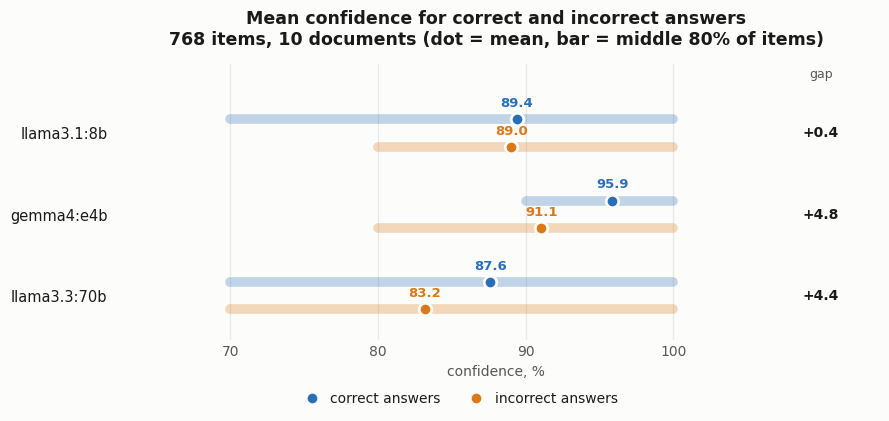

In [9]:
# Colours checked for colour-blind separation, not chosen by eye:
# blue/orange separate at dE 24 for every form of colour blindness, where the
# usual green/red pair sits at 8 -- near-identical to a deuteranope.
OK, BAD = '#2a6fb5', '#d97917'
INK, MUTED, SURFACE, GRID = '#1a1a19', '#575653', '#fcfcfb', '#e8e8e4'
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'text.color': INK, 'axes.labelcolor': MUTED,
    'xtick.color': MUTED, 'ytick.color': INK,
    'axes.edgecolor': '#d8d8d4', 'axes.titlecolor': INK,
    'font.size': 10, 'axes.titlesize': 12.5, 'axes.titleweight': 'bold',
    'legend.frameon': False,
})

def summarise(values):
    """Mean, and the band holding the middle 80% of the items."""
    v = values * 100
    return {'mean': v.mean(), 'lo': v.quantile(0.10), 'hi': v.quantile(0.90)}


stats = []
for model in MODELS:
    d = df[df['model'] == model]
    stats.append({'model': model,
                  'ok': summarise(d[d['correct']]['confidence']),
                  'bad': summarise(d[~d['correct']]['confidence'])})

fig, ax = plt.subplots(figsize=(9.0, 4.4))
OFFSET = 0.17

for i, s in enumerate(stats):
    y = -i
    for key, dy, colour, name in (('ok', OFFSET, OK, 'correct'),
                                  ('bad', -OFFSET, BAD, 'incorrect')):
        b = s[key]
        ax.plot([b['lo'], b['hi']], [y + dy] * 2, color=colour, alpha=0.28,
                linewidth=7, solid_capstyle='round', zorder=2)
        ax.plot(b['mean'], y + dy, 'o', color=colour, markersize=9,
                markeredgecolor=SURFACE, markeredgewidth=2, zorder=3,
                label=f'{name} answers' if i == 0 else None)
        ax.text(b['mean'], y + dy + 0.115, f"{b['mean']:.1f}", ha='center',
                va='bottom', fontsize=9.5, fontweight='bold', color=colour, zorder=4)

    # the gap between the two means, in the right-hand margin
    ax.text(110, y, f"{s['ok']['mean'] - s['bad']['mean']:+.1f}", ha='center',
            va='center', fontsize=10, fontweight='bold', color=INK)

ax.text(110, 0.72, 'gap', ha='center', va='center', fontsize=9, color=MUTED)
ax.set_yticks([-i for i in range(len(stats))])
ax.set_yticklabels([s['model'] for s in stats], fontsize=10.5)
ax.set_ylim(-len(stats) + 0.45, 0.85)
ax.set_xlim(62, 114)
ax.set_xticks([70, 80, 90, 100])
ax.set_xlabel('confidence, %')
ax.grid(axis='x', color=GRID, linewidth=0.9)
ax.set_axisbelow(True)
ax.legend(loc='upper center', bbox_to_anchor=(0.45, -0.14), ncol=2,
          handletextpad=0.3, columnspacing=1.6)
ax.set_title('Mean confidence for correct and incorrect answers\n'
             f'{len(df)} items, 10 documents '
             '(dot = mean, bar = middle 80% of items)', pad=14)
for side in ('top', 'right', 'left', 'bottom'):
    ax.spines[side].set_visible(False)
ax.tick_params(length=0)
plt.tight_layout()

out = Path('Report-doc/confidence_correct_vs_incorrect.png')
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=300, bbox_inches='tight', facecolor=SURFACE)
print(f'saved for slides -> {out}')
plt.show()


**The two dots sit almost on top of each other, and the bars overlap almost
completely.** The largest gap between the means is under 5 points. For llama3.3:70b
the two bars are the *same* — the middle 80% of its correct answers and the middle
80% of its wrong ones cover an identical range of confidence.

So knowing an answer's confidence tells you almost nothing about whether it is right.


## Conclusion

**The confidence score cannot be used to catch mistakes.** A high number does not
mean a correct label, so it must not be used to accept a label automatically.
